In [1]:
# import muon
import numpy as np
import mudata as md
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd

# clustering
from sklearn.cluster import KMeans

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/opt/miniconda3/envs/mudata/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
from graph import graph_construction
mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg2.h5mu")
mdata

/opt/miniconda3/envs/mudata/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/miniconda3/envs/mudata/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 2492 × 1267
  2 modalities
    RNA:	2492 x 984
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    Protein:	2492 x 283
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'

In [ ]:
from sklearn.neighbors import NearestNeighbors
rna_adata = mdata.mod['RNA']
coords = rna_adata.obsm['pos'] # or 'spatial'

# 2. Find distance to the CLOSEST neighbor for every cell (k=2 includes the cell itself)
nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
distances, indices = nbrs.kneighbors(coords)

nearest_dist = distances[:, 1]
mean_dist = np.mean(nearest_dist)
p90_dist = np.percentile(nearest_dist, 90)

print(f"Avg distance to nearest neighbor: {mean_dist:.2f}")
print(f"90% of cells have a neighbor within: {p90_dist:.2f}")
radius_choices = [mean_dist * 1.5, mean_dist * 3, mean_dist * 5, mean_dist * 10]
radius_choices = [round(x, 2) for x in radius_choices]

print(f"Selected Radius Choices: {radius_choices}")

Avg distance to nearest neighbor: 1.00
90% of cells have a neighbor within: 1.00
Selected Radius Choices: [1.5, 3.0, 5.0, 10.0]


Benchmarking KNN...
Benchmarking Radius...


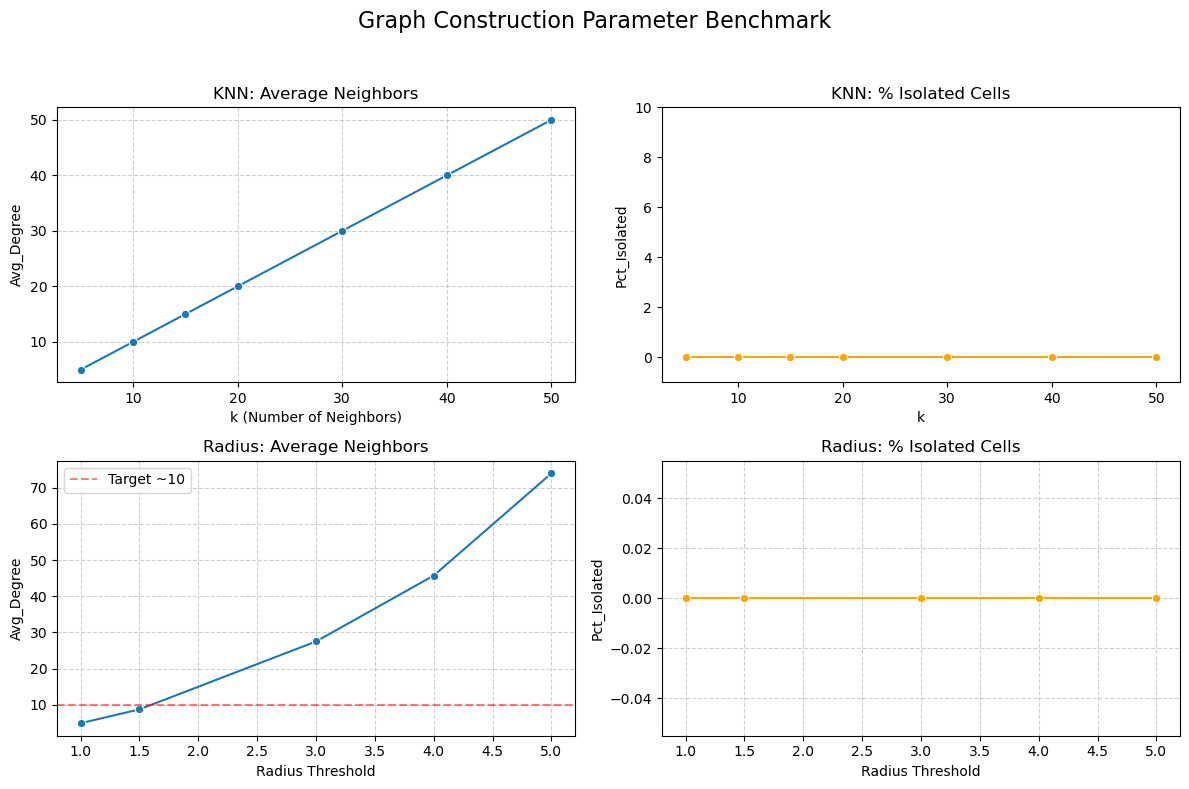


--- Radius Recommendations ---
Minimum radius for <1% isolated cells: 1.0
Detailed Stats for viable radii:
    Parameter  Avg_Degree  Pct_Isolated
7         1.0    4.910112           0.0
8         1.5    8.738363           0.0
9         3.0   27.498395           0.0
10        4.0   45.715088           0.0
11        5.0   73.969502           0.0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

def benchmark_graph_params(mdata, k_range, radius_range, spatial_key="pos"):
    if spatial_key in mdata.mod['RNA'].obsm:
        coords = mdata.mod['RNA'].obsm[spatial_key]
    else:
        raise ValueError(f"Spatial key '{spatial_key}' not found in mdata.mod['RNA'].obsm")

    results = []


    print("Benchmarking KNN...")
    nbrs_knn = NearestNeighbors(n_neighbors=max(k_range), algorithm='auto').fit(coords)
    
    for k in k_range:
        # kneighbors_graph returns an adjacency matrix (N x N)
        adj = nbrs_knn.kneighbors_graph(coords, n_neighbors=k, mode='connectivity')
        degrees = np.array(adj.sum(axis=1)).flatten()
        avg_deg = np.mean(degrees)
        pct_isolated = (np.sum(degrees == 0) / len(degrees)) * 100
        
        results.append({
            "Type": "KNN",
            "Parameter": k,
            "Avg_Degree": avg_deg,
            "Pct_Isolated": pct_isolated
        })

    print("Benchmarking Radius...")
    nbrs_rad = NearestNeighbors(radius=max(radius_range), algorithm='auto').fit(coords)
    
    for r in radius_range:
        adj = nbrs_rad.radius_neighbors_graph(coords, radius=r, mode='connectivity')
        
        degrees = np.array(adj.sum(axis=1)).flatten()
        avg_deg = np.mean(degrees)
        pct_isolated = (np.sum(degrees == 0) / len(degrees)) * 100
        
        results.append({
            "Type": "Radius",
            "Parameter": r,
            "Avg_Degree": avg_deg,
            "Pct_Isolated": pct_isolated
        })

    return pd.DataFrame(results)

def plot_benchmark_results(df):
    """
    Plots the benchmark metrics side-by-side.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Graph Construction Parameter Benchmark", fontsize=16)

    knn_df = df[df["Type"] == "KNN"]
    
    sns.lineplot(data=knn_df, x="Parameter", y="Avg_Degree", ax=axes[0, 0], marker="o")
    axes[0, 0].set_title("KNN: Average Neighbors")
    axes[0, 0].set_xlabel("k (Number of Neighbors)")
    axes[0, 0].grid(True, linestyle='--', alpha=0.6)
    
    sns.lineplot(data=knn_df, x="Parameter", y="Pct_Isolated", ax=axes[0, 1], marker="o", color="orange")
    axes[0, 1].set_title("KNN: % Isolated Cells")
    axes[0, 1].set_xlabel("k")
    axes[0, 1].set_ylim(-1, 10) # Zoom in near 0

    rad_df = df[df["Type"] == "Radius"]
    sns.lineplot(data=rad_df, x="Parameter", y="Avg_Degree", ax=axes[1, 0], marker="o")
    axes[1, 0].set_title("Radius: Average Neighbors")
    axes[1, 0].set_xlabel("Radius Threshold")
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)
    axes[1, 0].axhline(10, color='red', linestyle='--', alpha=0.5, label='Target ~10')
    axes[1, 0].legend()

    sns.lineplot(data=rad_df, x="Parameter", y="Pct_Isolated", ax=axes[1, 1], marker="o", color="orange")
    axes[1, 1].set_title("Radius: % Isolated Cells")
    axes[1, 1].set_xlabel("Radius Threshold")
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

k_test_range = [5, 10, 15, 20, 30, 40, 50]
radius_test_range = [1, 1.5, 3.0, 4, 5.0]
benchmark_df = benchmark_graph_params(mdata, k_test_range, radius_test_range, spatial_key="pos")
plot_benchmark_results(benchmark_df)
print("\n--- Radius Recommendations ---")
# Find smallest radius where isolation is low (< 1%)
viable_radii = benchmark_df[(benchmark_df["Type"]=="Radius") & (benchmark_df["Pct_Isolated"] < 1.0)]
if not viable_radii.empty:
    print(f"Minimum radius for <1% isolated cells: {viable_radii.iloc[0]['Parameter']}")
    print("Detailed Stats for viable radii:")
    print(viable_radii[["Parameter", "Avg_Degree", "Pct_Isolated"]].head())
else:
    print("No radius in range achieved <1% isolation. Try larger radii.")

In [21]:
from graph import graph_construction
import torch

rna_adata = mdata.mod['RNA']
coords = rna_adata.obsm['pos'] 

# 1. connectivy
print("Constructing Graph using Connectivity...")
for k in [6,10,30,50]:
    print(f"Constructing graph with k={k}...")
    position = rna_adata.obsm["pos"]
    mode = 'connectivity'
    e_index_conn, e_weight_conn = graph_construction(
        position, 
        k=k, 
        mode=mode
    )
    print(f"Edge Index Shape: {e_index_conn.shape}")
    print(f"Edge Weight Mean: {e_weight_conn.mean():.4f} ")
    graph_data = {
        'edge_index': e_index_conn,
        'edge_weight': e_weight_conn
    }
    save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_k{k}_conn.pt'
    torch.save(graph_data, save_path)
    # 2. similarity
    mode = 'similarity'
    e_index_sim, e_weight_sim = graph_construction(
        position, 
        k=k, 
        mode=mode,
        similarity_method='inverse'
    )
    print(f"Edge Index Shape: {e_index_sim.shape}")
    print(f"Edge Weight Mean: {e_weight_sim.mean():.4f} ")
    save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_k{k}_sim_inv.pt'
    torch.save(graph_data, save_path)
    # 3. similarity with gaussian
    e_index_sim_d, e_weight_sim_d = graph_construction( #sigma might be a parameter here.
    position, 
    k=k, 
    mode=mode,
    similarity_method='gaussian'
    )
    print(f"Edge Index Shape: {e_index_sim_d.shape}")
    print(f"Edge Weight Mean: {e_weight_sim_d.mean():.4f} ")
    save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_k{k}_sim_gau.pt'
    torch.save(graph_data, save_path)
    

Constructing Graph using Connectivity...
Constructing graph with k=6...
Edge Index Shape: torch.Size([2, 14952])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch.Size([2, 14952])
Edge Weight Mean: 0.8950 
Similarity Method: Gaussian. Using sigma=1.15
Edge Index Shape: torch.Size([2, 14952])
Edge Weight Mean: 0.6079 
Constructing graph with k=10...
Edge Index Shape: torch.Size([2, 24920])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch.Size([2, 24920])
Edge Weight Mean: 0.7738 
Similarity Method: Gaussian. Using sigma=1.39
Edge Index Shape: torch.Size([2, 24920])
Edge Weight Mean: 0.6085 
Constructing graph with k=30...
Edge Index Shape: torch.Size([2, 74760])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch.Size([2, 74760])
Edge Weight Mean: 0.5164 
Similarity Method: Gaussian. Using sigma=2.24
Edge Index Shape: torch.Size([2, 74760])
Edge Weight Mean: 0.6047 
Constructing graph with k=50...
Edge Index Shape: torch.Size([2, 124600])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch

In [46]:
import graph
import importlib
importlib.reload(graph)
from graph import graph_construction
k=1.6
edge_index, edge_weight = graph_construction(
    mdata.mod['RNA'].obsm['pos'],
    graph_type='radius',
    radius=1.6,        
    mode='connectivity'
)
print(f"Edge Index Shape: {edge_index.shape}")
print(f"Edge Weight Mean: {edge_weight.mean():.4f} ")
save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_r{k}_conn.pt'
torch.save(graph_data, save_path)

edge_index, edge_weight = graph_construction(
    mdata.mod['RNA'].obsm['pos'],
    graph_type='radius',
    radius=1.6,        
    mode='similarity', 
    similarity_method='inverse'
)
print(f"Edge Index Shape: {edge_index.shape}")
print(f"Edge Weight Mean: {edge_weight.mean():.4f} ")
save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_r{k}_sim_inv.pt'
torch.save(graph_data, save_path)

edge_index, edge_weight = graph_construction(
    mdata.mod['RNA'].obsm['pos'],
    graph_type='radius',
    radius=1.6,        
    mode='similarity', 
    similarity_method='gaussian'
)
print(f"Edge Index Shape: {edge_index.shape}")
print(f"Edge Weight Mean: {edge_weight.mean():.4f} ")
save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_r{k}_sim_gau.pt'
torch.save(graph_data, save_path)


Edge Index Shape: torch.Size([2, 19284])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch.Size([2, 19284])
Edge Weight Mean: 0.8551 
Edge Index Shape: torch.Size([2, 19284])
Edge Weight Mean: 0.6065 


In [50]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import torch
import scipy.sparse as sp
import os
os.environ["MKL_VERBOSE"] = "0"
os.environ["MKL_DISABLE_FAST_MM"] = "1"
import warnings
warnings.filterwarnings("ignore", message="Intel MKL")
warnings.filterwarnings("ignore", category=FutureWarning)


def compute_lisi(emb, labels, perplexity=30):
    n_neighbors = int(3 * perplexity)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(emb)
    distances, indices = nn.kneighbors(emb)
    indices = indices[:, 1:]  # drop self

    labels = np.array(labels)
    out = []

    for i in range(emb.shape[0]):
        neigh = labels[indices[i]]
        p = pd.value_counts(neigh) / len(neigh)
        entropy = -(p * np.log(p)).sum()
        out.append(np.exp(entropy))

    return np.array(out)


def compute_morani(choice, rna_adata):
    graph_choice = "5_conn" if choice == "5" else choice
    graph_path = f"/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_r{graph_choice}.pt"

    graph_data = torch.load(graph_path)
    edge_index = graph_data['edge_index'].cpu().numpy()   # (2, E)
    edge_weight = graph_data['edge_weight'].cpu().numpy() # (E,)
    n_cells = rna_adata.n_obs

    spatial_graph_sparse = sp.coo_matrix(
        (edge_weight, (edge_index[0], edge_index[1])),
        shape=(n_cells, n_cells)
    )

    # Replace connectivities with spatial graph
    rna_adata.obsp['connectivities'] = spatial_graph_sparse.tocsr()

    rna_moran = sc.metrics.morans_i(
        rna_adata,
        obsm="X_spatial_totalVI"   # vals = latent dims
        # use_graph=None -> uses 'connectivities' we just set
    )
    return rna_moran


# ---------- Main loop ----------
choices = [
    "1.6_conn", "1.6_sim_gau", "1.6_sim_inv"
]
save_dir = "/Users/momo/Documents/cs536r/spatial_totalvi/benchmark/results"
os.makedirs(save_dir, exist_ok=True)

mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg2.h5mu")
rna_adata_base = mdata.mod["RNA"]


metrics = []  

for i, choice in enumerate(choices):
    print(f"Processing model {choice} ...")

    rna_adata = rna_adata_base.copy()

    embeddings = pd.read_table(
        f"../../data/latents/totalvi_r{choice}_1layer_SGC_k1_latents.tsv",
        header=None, sep="\t"
    ).to_numpy()

    umap_rerun = pd.read_table(
        f"../../data/latents/totalvi_r{choice}_1layer_SGC_k1_umaplatents.tsv",
        header=None, sep="\t"
    ).to_numpy()

    rna_adata.obsm["X_spatial_totalVI"] = embeddings
    rna_adata.obsm["X_umap"] = umap_rerun

    sc.pp.neighbors(rna_adata, use_rep="X_spatial_totalVI", n_neighbors=30)
    sc.tl.umap(rna_adata)

    # ---------- Moran's I ----------
    rna_moran = compute_morani(choice, rna_adata)
    mean_moran = float(rna_moran.mean())

    # ---------- Clustering ----------
    kmeans = KMeans(n_clusters=5, random_state=0).fit(embeddings)
    rna_adata.obs['kmeans5'] = kmeans.labels_.astype(str)

    sc.tl.leiden(rna_adata, key_added="leiden_eval", resolution=0.7, random_state=0)
    sc.tl.louvain(rna_adata, key_added="louvain_eval", resolution=0.7, random_state=0)

    # ---------- cLISI ----------
    cLISI_kmean   = compute_lisi(embeddings, rna_adata.obs["kmeans5"])
    cLISI_louvain = compute_lisi(embeddings, rna_adata.obs["louvain_eval"])
    cLISI_leiden  = compute_lisi(embeddings, rna_adata.obs["leiden_eval"])

    mean_cLISI_kmeans   = float(cLISI_kmean.mean())
    mean_cLISI_louvain  = float(cLISI_louvain.mean())
    mean_cLISI_leiden   = float(cLISI_leiden.mean())

    # ---------- DBI ----------
    dbi_kmeans  = float(davies_bouldin_score(embeddings, kmeans.labels_))
    dbi_louvain = float(davies_bouldin_score(embeddings, rna_adata.obs["louvain_eval"].astype(int).values))
    dbi_leiden  = float(davies_bouldin_score(embeddings, rna_adata.obs["leiden_eval"].astype(int).values))


    # ---------- Collect metrics ----------
    metrics.append({
        "model": choice,
        "mean_moran": mean_moran,
        "mean_cLISI_kmeans5": mean_cLISI_kmeans,
        "mean_cLISI_louvain": mean_cLISI_louvain,
        "mean_cLISI_leiden": mean_cLISI_leiden,
        "dbi_kmeans": dbi_kmeans,
        "dbi_louvain": dbi_louvain,
        "dbi_leiden": dbi_leiden,
    })


metrics_df = pd.DataFrame(metrics)

metrics_df.to_csv(
    os.path.join(save_dir, "radius_graph_metrics.tsv"),
    sep="\t",
    index=False
)
metrics_df

Processing model 1.6_conn ...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Processing model 1.6_sim_gau ...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require In

,model,mean_moran,mean_cLISI_kmeans5,mean_cLISI_louvain,mean_cLISI_leiden,dbi_kmeans,dbi_louvain,dbi_leiden
0,1.6_conn,0.150878,1.934175,7.141415,7.356414,2.172575,11.725316,14.063439
1,1.6_sim_gau,0.132336,1.915038,7.460266,7.441187,2.333754,10.310612,11.055090
2,1.6_sim_inv,0.146874,1.762379,7.328336,7.394908,2.253567,11.253191,11.719095


In [14]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import torch
import scipy.sparse as sp
import os
os.environ["MKL_VERBOSE"] = "0"
os.environ["MKL_DISABLE_FAST_MM"] = "1"
import warnings
warnings.filterwarnings("ignore", message="Intel MKL")
warnings.filterwarnings("ignore", category=FutureWarning)


def compute_lisi(emb, labels, perplexity=30):
    n_neighbors = int(3 * perplexity)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(emb)
    distances, indices = nn.kneighbors(emb)
    indices = indices[:, 1:]  # drop self

    labels = np.array(labels)
    out = []

    for i in range(emb.shape[0]):
        neigh = labels[indices[i]]
        p = pd.value_counts(neigh) / len(neigh)
        entropy = -(p * np.log(p)).sum()
        out.append(np.exp(entropy))

    return np.array(out)


def compute_morani(choice, rna_adata):
    graph_choice = "5_conn" if choice == "5" else choice
    graph_path = f"/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_k{graph_choice}.pt"

    graph_data = torch.load(graph_path)
    edge_index = graph_data['edge_index'].cpu().numpy()   # (2, E)
    edge_weight = graph_data['edge_weight'].cpu().numpy() # (E,)
    n_cells = rna_adata.n_obs

    spatial_graph_sparse = sp.coo_matrix(
        (edge_weight, (edge_index[0], edge_index[1])),
        shape=(n_cells, n_cells)
    )

    # Replace connectivities with spatial graph
    rna_adata.obsp['connectivities'] = spatial_graph_sparse.tocsr()

    rna_moran = sc.metrics.morans_i(
        rna_adata,
        obsm="X_spatial_totalVI"   # vals = latent dims
        # use_graph=None -> uses 'connectivities' we just set
    )
    return rna_moran


# ---------- Main loop ----------
choices = [
    "5_conn", "5_sim_gau", "5_sim_inv",
    "6_sim_gau", "6_sim_gau", "6_sim_inv",
    "10_conn", "10_sim_gau", "10_sim_inv",
    "20_conn", "20_sim_gau", "20_sim_inv",
    "30_conn", "30_sim_gau", "30_sim_inv",
    "50_conn", "50_sim_gau", "50_sim_inv"
]
save_dir = "/Users/momo/Documents/cs536r/spatial_totalvi/benchmark/results"
os.makedirs(save_dir, exist_ok=True)

mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg2.h5mu")
rna_adata_base = mdata.mod["RNA"]


metrics = []  

for i, choice in enumerate(choices):
    print(f"Processing model {choice} ...")

    rna_adata = rna_adata_base.copy()

    embeddings = pd.read_table(
        f"../../data/latents/totalvi_k{choice}_1layer_SGC_k1_latents.tsv",
        header=None, sep="\t"
    ).to_numpy()

    umap_rerun = pd.read_table(
        f"../../data/latents/totalvi_k{choice}_1layer_SGC_k1_umaplatents.tsv",
        header=None, sep="\t"
    ).to_numpy()

    rna_adata.obsm["X_spatial_totalVI"] = embeddings
    rna_adata.obsm["X_umap"] = umap_rerun

    sc.pp.neighbors(rna_adata, use_rep="X_spatial_totalVI", n_neighbors=30)
    sc.tl.umap(rna_adata)

    # ---------- Moran's I ----------
    rna_moran = compute_morani(choice, rna_adata)
    mean_moran = float(rna_moran.mean())

    # ---------- Clustering ----------
    kmeans = KMeans(n_clusters=5, random_state=0).fit(embeddings)
    rna_adata.obs['kmeans5'] = kmeans.labels_.astype(str)

    sc.tl.leiden(rna_adata, key_added="leiden_eval", resolution=0.7, random_state=0)
    sc.tl.louvain(rna_adata, key_added="louvain_eval", resolution=0.7, random_state=0)

    # ---------- cLISI ----------
    cLISI_kmean   = compute_lisi(embeddings, rna_adata.obs["kmeans5"])
    cLISI_louvain = compute_lisi(embeddings, rna_adata.obs["louvain_eval"])
    cLISI_leiden  = compute_lisi(embeddings, rna_adata.obs["leiden_eval"])

    mean_cLISI_kmeans   = float(cLISI_kmean.mean())
    mean_cLISI_louvain  = float(cLISI_louvain.mean())
    mean_cLISI_leiden   = float(cLISI_leiden.mean())

    # ---------- DBI ----------
    dbi_kmeans  = float(davies_bouldin_score(embeddings, kmeans.labels_))
    dbi_louvain = float(davies_bouldin_score(embeddings, rna_adata.obs["louvain_eval"].astype(int).values))
    dbi_leiden  = float(davies_bouldin_score(embeddings, rna_adata.obs["leiden_eval"].astype(int).values))


    # ---------- Collect metrics ----------
    metrics.append({
        "model": choice,
        "mean_moran": mean_moran,
        "mean_cLISI_kmeans5": mean_cLISI_kmeans,
        "mean_cLISI_louvain": mean_cLISI_louvain,
        "mean_cLISI_leiden": mean_cLISI_leiden,
        "dbi_kmeans": dbi_kmeans,
        "dbi_louvain": dbi_louvain,
        "dbi_leiden": dbi_leiden,
    })


metrics_df = pd.DataFrame(metrics)

metrics_df.to_csv(
    os.path.join(save_dir, "knn_graph_metrics.tsv"),
    sep="\t",
    index=False
)
metrics_df

Processing model 5_conn ...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Processing model 5_sim_gau ...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(

,model,mean_moran,mean_cLISI_kmeans5,mean_cLISI_louvain,mean_cLISI_leiden,dbi_kmeans,dbi_louvain,dbi_leiden
0,5_conn,0.535132,1.768712,9.619024,10.644405,1.630314,6.451023,7.542200
1,5_sim_gau,0.505906,1.778137,9.796689,10.782881,1.547659,7.071640,8.298624
2,5_sim_inv,0.551232,1.651858,9.871005,10.932094,1.580255,7.187588,8.470911
3,6_sim_gau,0.493029,1.684462,9.726859,9.732484,1.476536,5.473685,6.976904
4,6_sim_gau,0.493029,1.684462,9.726859,9.732484,1.476536,5.473685,6.976904
5,6_sim_inv,0.492474,1.663297,9.758824,9.802829,1.412577,5.364012,7.383773
6,10_conn,0.511447,1.500498,9.820791,8.556541,1.378487,7.728069,9.178059
7,10_sim_gau,0.468159,1.440549,10.437547,9.083898,1.244190,9.010304,9.885272
8,10_sim_inv,0.451364,1.523859,10.148047,8.744383,1.205441,8.241448,9.304050
9,20_conn,0.362846,1.496281,8.219830,8.350823,1.314619,11.095217,10.035390


In [12]:
import os
choice = "20_conn"
file_path = f"../../data/latents/totalvi_k{choice}_1layer_SGC_k1_latents.tsv"

# 1. Check if file exists
if os.path.exists(file_path):
    print("✅ File exists.")
    
    # 2. Check if it is readable
    if os.access(file_path, os.R_OK):
        print("✅ File is readable.")
        embeddings = pd.read_table(
        f"../../data/latents/totalvi_k{choice}_1layer_SGC_k1_latents.tsv",
        header=None, sep="\t"
        ).to_numpy()
    else:
        print("❌ File exists but is NOT readable (check permissions).")
else:
    print(f"❌ File not found at: {file_path}")
    print("   Double check the filename or directory spelling.")

✅ File exists.
✅ File is readable.


In [21]:
import pandas as pd
import os

knn_path = os.path.join(save_dir, "knn_graph_metrics.tsv")
rad_path = os.path.join(save_dir, "radius_graph_metrics.tsv")
df_knn = pd.read_csv(knn_path, sep='\t') if os.path.exists(knn_path) else pd.DataFrame()
df_rad = pd.read_csv(rad_path, sep='\t') if os.path.exists(rad_path) else pd.DataFrame()
if not df_knn.empty:
    df_knn['graph_type'] = 'KNN'
if not df_rad.empty:
    df_rad['graph_type'] = 'Radius'
metrics_df = pd.concat([df_knn, df_rad], ignore_index=True)
df = metrics_df.copy()

df['model'] = df['model'].astype(str).replace('5', '5_conn')

def parse_model_info(row):
    parts = row['model'].split('_')
    val_str = parts[0] 
    
    if len(parts) > 1:
        method_raw = '_'.join(parts[1:])
    else:
        method_raw = 'conn' 
        
    return val_str, method_raw

df[['param_str', 'method']] = df.apply(parse_model_info, axis=1, result_type='expand')

df['k'] = df.apply(lambda x: int(float(x['param_str'])) if x['graph_type'] == 'KNN' else None, axis=1)
df['radius'] = df.apply(lambda x: float(x['param_str']) if x['graph_type'] == 'Radius' else None, axis=1)

method_map = {
    'conn': 'Connectivity (Binary)', 
    'sim_gau': 'Gaussian Kernel', 
    'sim_inv': 'Inverse Distance'
}
df['method_label'] = df['method'].map(method_map).fillna(df['method'])
print("Combined Data Shape:", df.shape)
df

Combined Data Shape: (21, 14)


,model,mean_moran,mean_cLISI_kmeans5,mean_cLISI_louvain,mean_cLISI_leiden,dbi_kmeans,dbi_louvain,dbi_leiden,graph_type,param_str,method,k,radius,method_label
0,5_conn,0.535132,1.768712,9.619024,10.644405,1.630314,6.451023,7.542200,KNN,5,conn,5.0,NaN,Connectivity (Binary)
1,5_sim_gau,0.505906,1.778137,9.796689,10.782881,1.547659,7.071640,8.298624,KNN,5,sim_gau,5.0,NaN,Gaussian Kernel
2,5_sim_inv,0.551232,1.651858,9.871005,10.932094,1.580255,7.187588,8.470911,KNN,5,sim_inv,5.0,NaN,Inverse Distance
3,6_sim_gau,0.493029,1.684462,9.726859,9.732484,1.476536,5.473685,6.976904,KNN,6,sim_gau,6.0,NaN,Gaussian Kernel
4,6_sim_gau,0.493029,1.684462,9.726859,9.732484,1.476536,5.473685,6.976904,KNN,6,sim_gau,6.0,NaN,Gaussian Kernel
5,6_sim_inv,0.492474,1.663297,9.758824,9.802829,1.412577,5.364012,7.383773,KNN,6,sim_inv,6.0,NaN,Inverse Distance
6,10_conn,0.511447,1.500498,9.820791,8.556541,1.378487,7.728069,9.178059,KNN,10,conn,10.0,NaN,Connectivity (Binary)
7,10_sim_gau,0.468159,1.440549,10.437547,9.083898,1.244190,9.010304,9.885272,KNN,10,sim_gau,10.0,NaN,Gaussian Kernel
8,10_sim_inv,0.451364,1.523859,10.148047,8.744383,1.205441,8.241448,9.304050,KNN,10,sim_inv,10.0,NaN,Inverse Distance
9,20_conn,0.362846,1.496281,8.219830,8.350823,1.314619,11.095217,10.035390,KNN,20,conn,20.0,NaN,Connectivity (Binary)


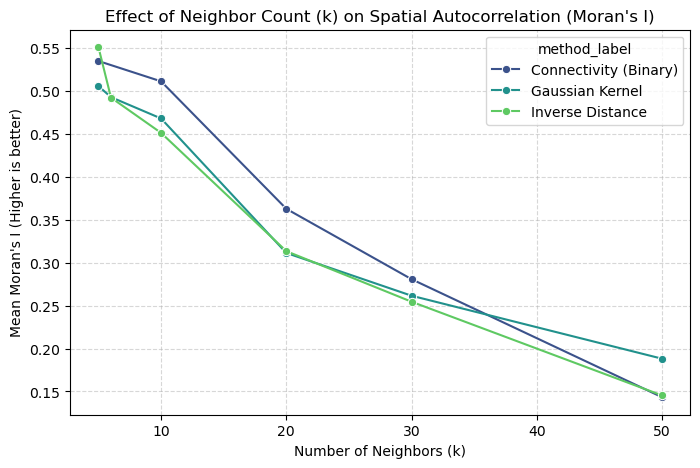

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
knn_df = df[df['graph_type'] == 'KNN']
plt.figure(figsize=(8, 5))
sns.lineplot(data=knn_df, x='k', y='mean_moran', hue='method_label', marker='o', palette='viridis')
plt.title("Effect of Neighbor Count (k) on Spatial Autocorrelation (Moran's I)")
plt.ylabel("Mean Moran's I (Higher is better)")
plt.xlabel("Number of Neighbors (k)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

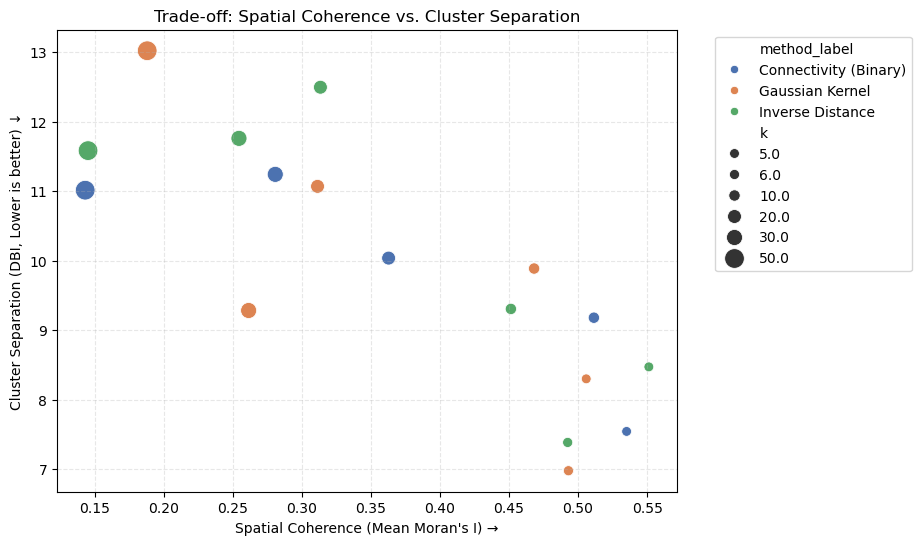

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, 
    x='mean_moran', 
    y='dbi_leiden', 
    hue='method_label', 
    size='k', 
    sizes=(50, 200), 
    palette='deep'
)
plt.title("Trade-off: Spatial Coherence vs. Cluster Separation")
plt.xlabel("Spatial Coherence (Mean Moran's I) →")
plt.ylabel("Cluster Separation (DBI, Lower is better) ↓")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

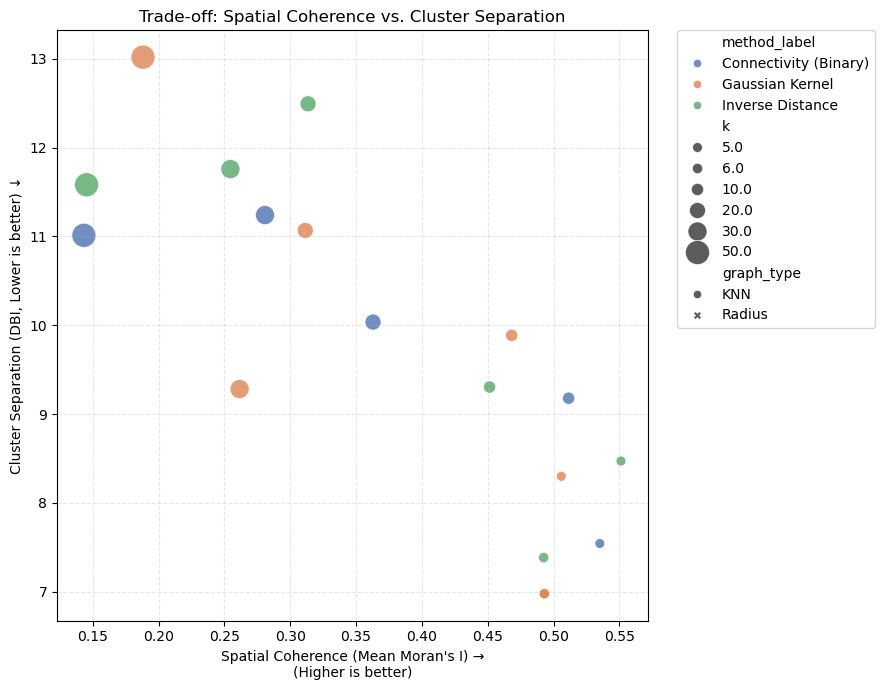

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

df['param_value'] = df['k'].fillna(df['radius'])
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df, 
    x='mean_moran', 
    y='dbi_leiden', 
    hue='method_label',
    style='graph_type',    
    size='k',   
    sizes=(50, 300),       
    alpha=0.8,             
    palette='deep'
)

plt.title("Trade-off: Spatial Coherence vs. Cluster Separation")
plt.xlabel("Spatial Coherence (Mean Moran's I) →\n(Higher is better)")
plt.ylabel("Cluster Separation (DBI, Lower is better) ↓")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

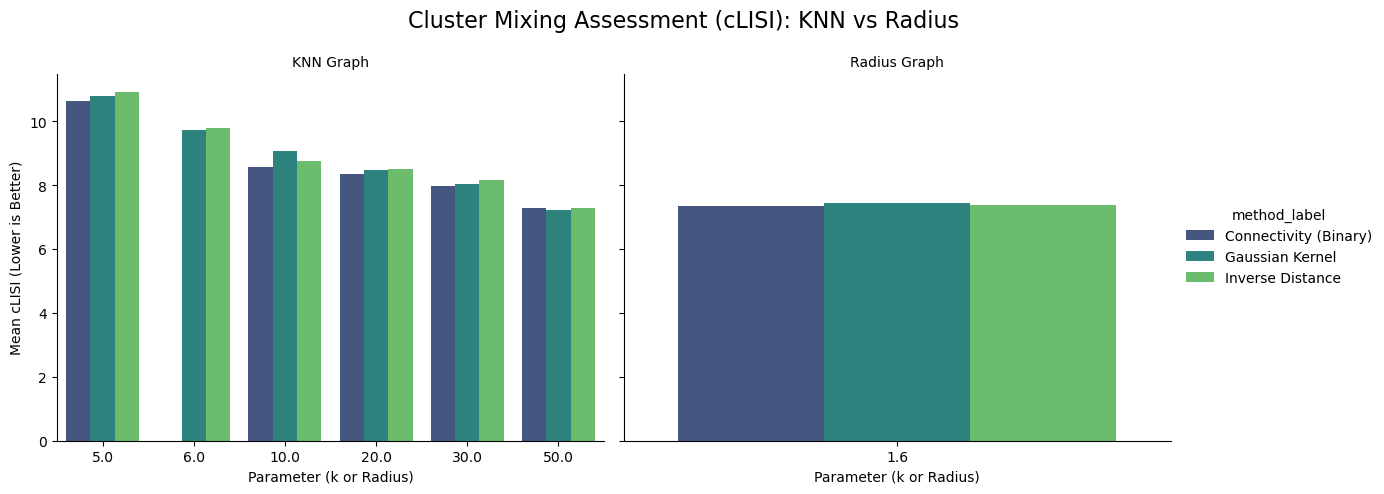

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df, 
    kind="bar", 
    x="param_value", 
    y="mean_cLISI_leiden", 
    hue="method_label", 
    col="graph_type",    
    sharex=False,       
    height=5, 
    aspect=1.2,
    palette="viridis"
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Cluster Mixing Assessment (cLISI): KNN vs Radius", fontsize=16)
g.set_axis_labels("Parameter (k or Radius)", "Mean cLISI (Lower is Better)")
g.set_titles("{col_name} Graph")

plt.show()

In [30]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import muon as md
import torch
import scipy.sparse as sp
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import davies_bouldin_score
import warnings
# Configs
os.environ["MKL_VERBOSE"] = "0"
os.environ["MKL_DISABLE_FAST_MM"] = "1"
warnings.filterwarnings("ignore")


def compute_morani(choice, rna_adata):
    graph_path = f"/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_{choice}.pt"

    graph_data = torch.load(graph_path)
    edge_index = graph_data['edge_index'].cpu().numpy()   # (2, E)
    edge_weight = graph_data['edge_weight'].cpu().numpy() # (E,)
    n_cells = rna_adata.n_obs

    spatial_graph_sparse = sp.coo_matrix(
        (edge_weight, (edge_index[0], edge_index[1])),
        shape=(n_cells, n_cells)
    )

    # Replace connectivities with spatial graph
    rna_adata.obsp['connectivities'] = spatial_graph_sparse.tocsr()

    rna_moran = sc.metrics.morans_i(
        rna_adata,
        obsm="X_spatial_totalVI"   # vals = latent dims
        # use_graph=None -> uses 'connectivities' we just set
    )
    return rna_moran

save_dir = "/Users/momo/Documents/cs536r/spatial_totalvi/benchmark/results"
os.makedirs(save_dir, exist_ok=True)

# Load Data
mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg2.h5mu")
rna_adata_base = mdata.mod["RNA"]

choices = [
    "k20_conn", "k5_conn", "k5_sim_gau", "k5_sim_inv",
    "k6_conn", "k6_sim_gau", "k6_sim_inv",
    "k10_conn", "k10_sim_gau", "k10_sim_inv",
    "k20_sim_gau", "k20_sim_inv",
    "k30_conn", "k30_sim_gau", "k30_sim_inv",
    "k50_conn", "k50_sim_gau", "k50_sim_inv",
    "r1.6_conn", "r1.6_sim_gau", "r1.6_sim_inv"
]


dist_data = []

for i, choice in enumerate(choices):
    print(f"Processing model {choice} ...")
    
    # Load Embeddings
    emb_path = f"../../data/latents/totalvi_{choice}_1layer_SGC_k1_latents.tsv"
    if not os.path.exists(emb_path):
        print(f"Skipping {choice}, file not found.")
        continue
        
    embeddings = pd.read_table(emb_path, header=None, sep="\t").to_numpy()
    rna_adata = rna_adata_base.copy()
    rna_adata.obsm["X_spatial_totalVI"] = embeddings

    # 1. Moran's I (Per Dimension)
    try:
        rna_moran = compute_morani(choice, rna_adata)
        for val in rna_moran:
            dist_data.append({"model": choice, "metric_type": "Moran_I", "value": float(val)})
    except Exception as e:
        print(f"Moran error for {choice}: {e}")

    # 2. cLISI (Per Cell)
    sc.pp.neighbors(rna_adata, use_rep="X_spatial_totalVI", n_neighbors=30)
    sc.tl.leiden(rna_adata, key_added="leiden_eval", resolution=0.7, random_state=0)
    
    clisi_vals = compute_lisi(embeddings, rna_adata.obs["leiden_eval"])
    for val in clisi_vals:
        dist_data.append({"model": choice, "metric_type": "cLISI_leiden", "value": float(val)})

# Save raw distribution data
pd.DataFrame(dist_data).to_csv(os.path.join(save_dir, "distribution_metrics.tsv"), sep="\t", index=False)
print("Done. Saved distribution_metrics.tsv")

Processing model k20_conn ...
Processing model k5_conn ...
Processing model k5_sim_gau ...
Processing model k5_sim_inv ...
Processing model k6_conn ...
Processing model k6_sim_gau ...
Processing model k6_sim_inv ...
Processing model k10_conn ...
Processing model k10_sim_gau ...
Processing model k10_sim_inv ...
Processing model k20_sim_gau ...
Processing model k20_sim_inv ...
Processing model k30_conn ...
Processing model k30_sim_gau ...
Processing model k30_sim_inv ...
Processing model k50_conn ...
Processing model k50_sim_gau ...
Processing model k50_sim_inv ...
Processing model r1.6_conn ...
Processing model r1.6_sim_gau ...
Processing model r1.6_sim_inv ...
Done. Saved distribution_metrics.tsv


In [31]:
pd.DataFrame(dist_data)

,model,metric_type,value
0,k20_conn,Moran_I,0.598643
1,k20_conn,Moran_I,0.447353
2,k20_conn,Moran_I,0.379813
3,k20_conn,Moran_I,0.486144
4,k20_conn,Moran_I,0.255308
...,...,...,...
52747,r1.6_sim_inv,cLISI_leiden,1.950817
52748,r1.6_sim_inv,cLISI_leiden,1.395776
52749,r1.6_sim_inv,cLISI_leiden,1.000000
52750,r1.6_sim_inv,cLISI_leiden,1.157364


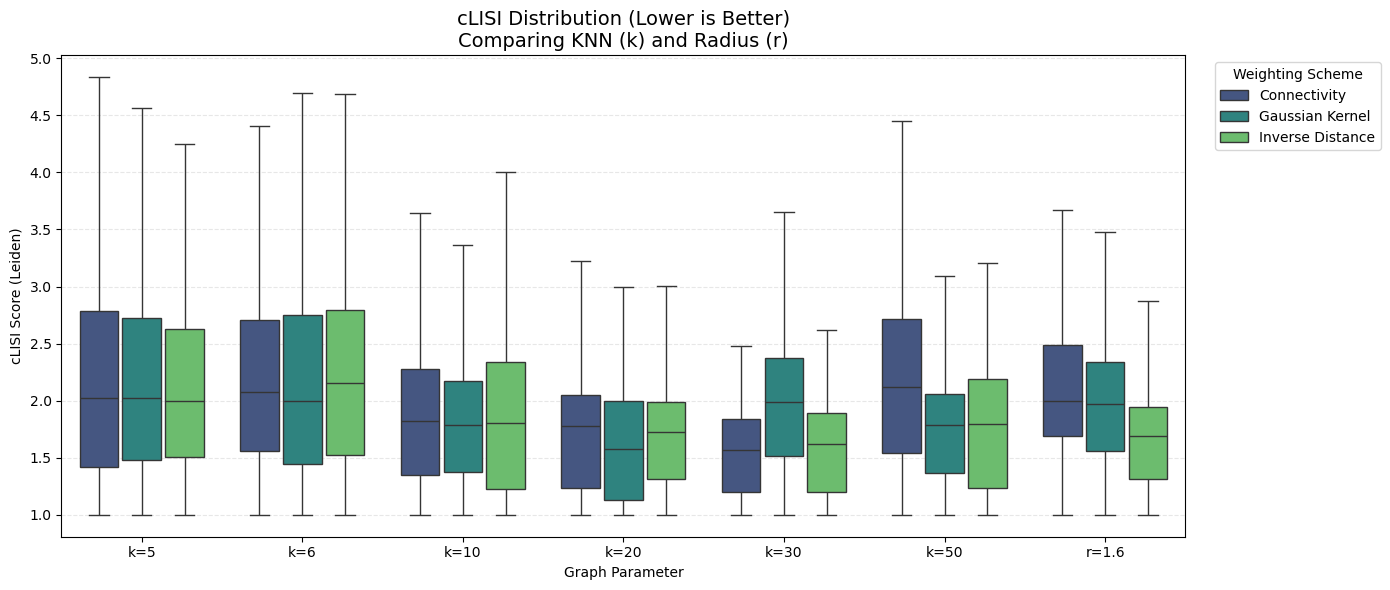

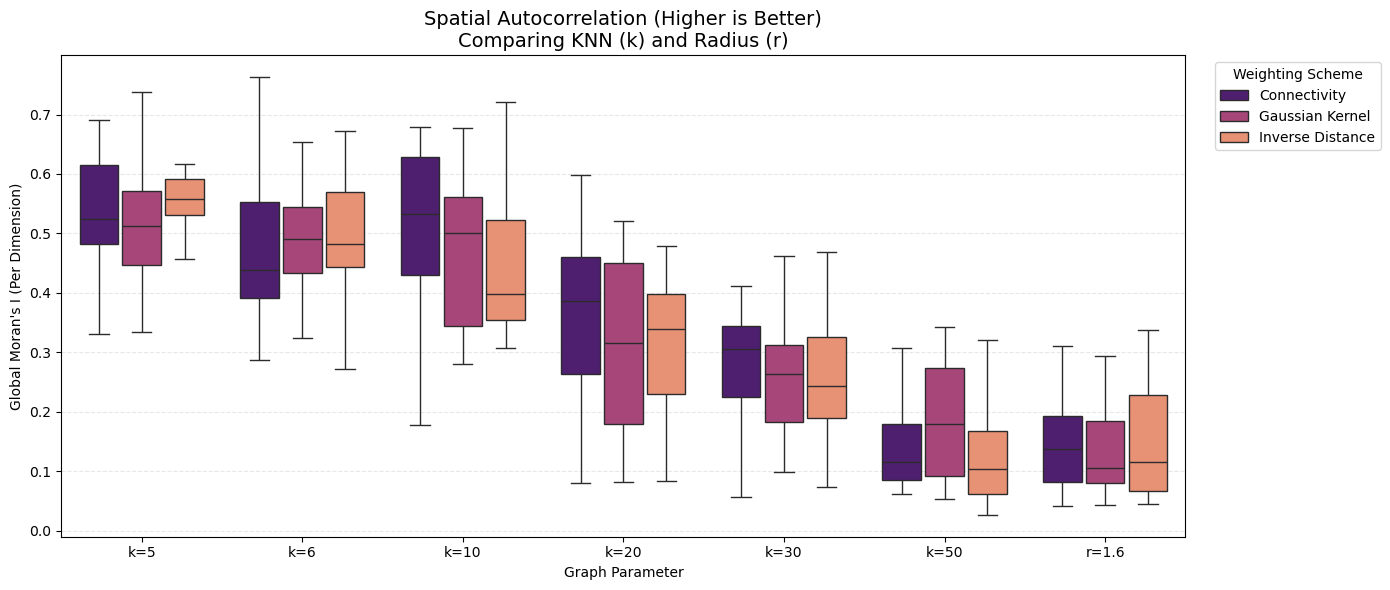

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

save_dir = "/Users/momo/Documents/cs536r/spatial_totalvi/benchmark/results"

file_path = os.path.join(save_dir, "distribution_metrics.tsv") 

df = pd.read_csv(file_path, sep='\t')

df['model'] = df['model'].astype(str).replace('5', '5_conn')

def parse_and_label(row):
    parts = row['model'].split('_')
    val_str = parts[0]
    if len(parts) > 1:
        method_raw = '_'.join(parts[1:])
    else:
        method_raw = 'conn'
        
    method_map = {
        'conn': 'Connectivity', 
        'sim_gau': 'Gaussian Kernel', 
        'sim_inv': 'Inverse Distance'
    }
    method_label = method_map.get(method_raw, method_raw)

    if '.' in val_str: 
        g_type = 'Radius'
        val = float(val_str.replace('r', ''))
        param_label = f"r={val}"
        sort_key = (1, val) 
    else: 
        g_type = 'KNN'
        val = int(val_str.replace('k', ''))
        param_label = f"k={val}"
        sort_key = (0, val) 
        
    return param_label, sort_key, method_label

# Apply logic
parsed_data = df.apply(parse_and_label, axis=1, result_type='expand')
df[['param_label', 'sort_key', 'method_label']] = parsed_data

# 3. Sorting (Crucial Step)
# Sort dataframe so seaborn plots in the correct order (k=5, k=10... then r=1.6)
df = df.sort_values(by=['sort_key', 'method_label'])

# =========================================================
# Plot 1: cLISI Distribution (Combined)
# =========================================================
subset_clisi = df[df['metric_type'] == 'cLISI_leiden']

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=subset_clisi,
    x="param_label",      # Unified X-axis
    y="value",
    hue="method_label",
    palette="viridis",
    showfliers=False,     # Hide outliers for cleaner view
    gap=0.1
)
plt.title("cLISI Distribution (Lower is Better)\nComparing KNN (k) and Radius (r)", fontsize=14)
plt.xlabel("Graph Parameter")
plt.ylabel("cLISI Score (Leiden)")
plt.legend(title="Weighting Scheme", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "boxplot_combined_cLISI.png"), bbox_inches='tight')
plt.show()

# =========================================================
# Plot 2: Moran's I Distribution (Combined)
# =========================================================
subset_moran = df[df['metric_type'] == 'Moran_I']

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=subset_moran,
    x="param_label",
    y="value",
    hue="method_label",
    palette="magma",
    showfliers=False,
    gap=0.1
)
plt.title("Spatial Autocorrelation (Higher is Better)\nComparing KNN (k) and Radius (r)", fontsize=14)
plt.xlabel("Graph Parameter")
plt.ylabel("Global Moran's I (Per Dimension)")
plt.legend(title="Weighting Scheme", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "boxplot_combined_MoranI.png"), bbox_inches='tight')
plt.show()

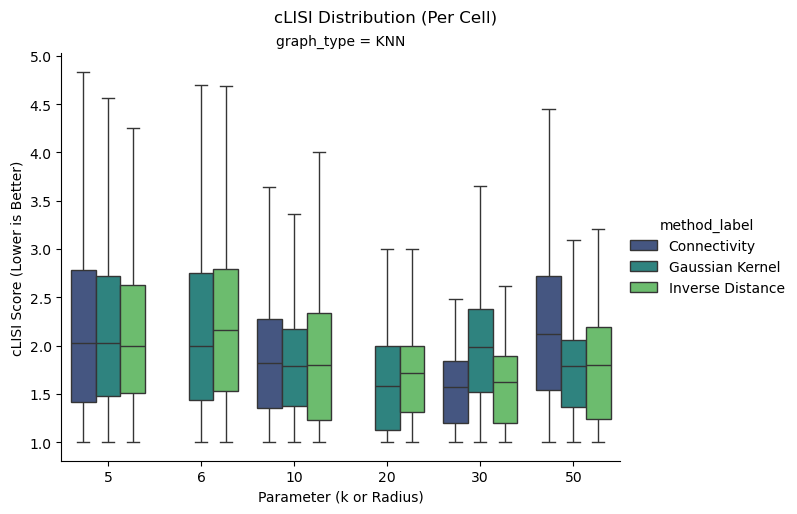

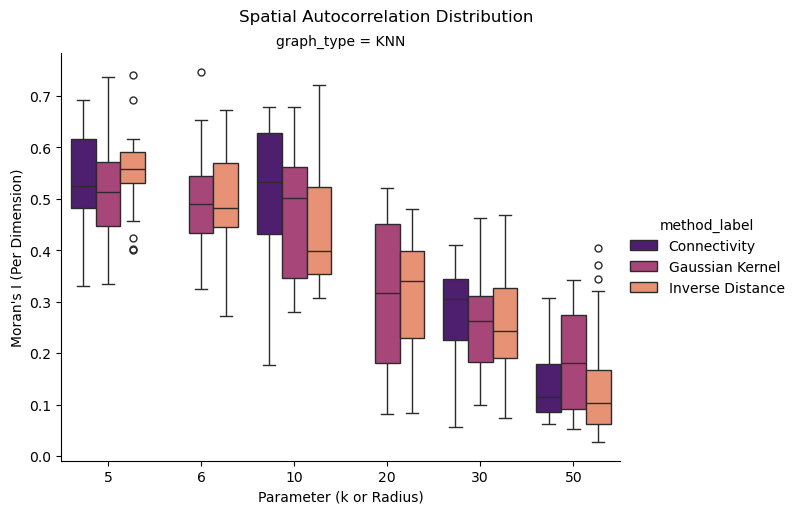

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

save_dir = "/Users/momo/Documents/cs536r/spatial_totalvi/benchmark/results"
file_path = os.path.join(save_dir, "knn_distribution_metrics.tsv")

# Read Data
df = pd.read_csv(file_path, sep='\t')

# Parsing Logic
df['model'] = df['model'].astype(str).replace('5', '5_conn')

def parse_model(row):
    parts = row['model'].split('_')
    val_str = parts[0]
    method_raw = '_'.join(parts[1:]) if len(parts) > 1 else 'conn'
    
    # Detect if it is KNN (int) or Radius (float)
    # Simple heuristic: if it contains '.', it's likely a radius float
    if '.' in val_str: 
        g_type = 'Radius'
        p_val = float(val_str)
    else:
        g_type = 'KNN'
        p_val = int(val_str)
        
    return g_type, p_val, method_raw

df[['graph_type', 'param_value', 'method']] = df.apply(parse_model, axis=1, result_type='expand')

method_map = {
    'conn': 'Connectivity', 
    'sim_gau': 'Gaussian Kernel', 
    'sim_inv': 'Inverse Distance'
}
df['method_label'] = df['method'].map(method_map).fillna(df['method'])

# Plot 1: cLISI Distribution
subset_clisi = df[df['metric_type'] == 'cLISI_leiden']

g1 = sns.catplot(
    data=subset_clisi,
    kind="box",
    x="param_value",
    y="value",
    hue="method_label",
    col="graph_type",
    sharex=False,
    height=5, 
    aspect=1.3,
    palette="viridis",
    showfliers=False 
)
g1.set_axis_labels("Parameter (k or Radius)", "cLISI Score (Lower is Better)")
g1.fig.suptitle("cLISI Distribution (Per Cell)", y=1.02)
plt.savefig(os.path.join(save_dir, "boxplot_cLISI.png"), bbox_inches='tight')
plt.show()

# Plot 2: Moran's I Distribution
subset_moran = df[df['metric_type'] == 'Moran_I']

g2 = sns.catplot(
    data=subset_moran,
    kind="box",
    x="param_value",
    y="value",
    hue="method_label",
    col="graph_type",
    sharex=False,
    height=5, 
    aspect=1.3,
    palette="magma"
)
g2.set_axis_labels("Parameter (k or Radius)", "Moran's I (Per Dimension)")
g2.fig.suptitle("Spatial Autocorrelation Distribution", y=1.02)
plt.savefig(os.path.join(save_dir, "boxplot_MoranI.png"), bbox_inches='tight')
plt.show()